In [1]:
# Imports, env vars, logging/warning suppression

%env MUJOCO_GL=egl
import datetime
import functools
import os
import time
import warnings

import jax
import jax.numpy as jp
import matplotlib.pyplot as plt
import mediapy as media
import mujoco
import numpy as np
import warp as wp
from absl import logging
from brax.training.agents.ppo import networks as ppo_networks
from brax.training.agents.ppo import train as ppo
from etils import epath
from mujoco_playground import registry, wrapper

import twmr  # noqa: F401 — registers TWMRLegFlat

wp.config.quiet = True
xla_flags = os.environ.get("XLA_FLAGS", "")
xla_flags += " --xla_gpu_triton_gemm_any=True"
os.environ["XLA_FLAGS"] = xla_flags
os.environ["XLA_PYTHON_CLIENT_PREALLOCATE"] = "false"
logging.set_verbosity(logging.WARNING)
warnings.filterwarnings("ignore", category=RuntimeWarning)
warnings.filterwarnings("ignore", category=DeprecationWarning)
media.set_ffmpeg("/bigdata/rhome/jbuh2025/Transformable-Leg-Wheel-Robot/.pixi/envs/default/bin/ffmpeg")

print("jax:", jax.__version__, " |  device:", jax.default_backend())

env: MUJOCO_GL=egl
jax: 0.8.2  |  device: gpu


In [2]:
# ── Training config ───────────────────────────────────────────────────────────
# ENV_NAME             = "TWMRLegFlatRawTorques" 
ENV_NAME             = "TWMRLegFlat"  # With PD controller
SEED                 = 1
NUM_TIMESTEPS        = 10_000_000
EPISODE_LENGTH       = 250        # 5 s at ctrl_dt = 0.02 s/step
NUM_ENVS             = 1024
NUM_EVAL_ENVS        = 128
NUM_EVALS            = 20         # evals every 5 % → hits 5, 10, …, 100 %
UNROLL_LENGTH        = 10
BATCH_SIZE           = 256
NUM_MINIBATCHES      = 8
NUM_UPDATES_PER_BATCH = 8
LEARNING_RATE        = 5e-4
ENTROPY_COST         = 5e-3
DISCOUNTING          = 0.97
REWARD_SCALING       = 1.0
CLIPPING_EPSILON     = 0.3
MAX_GRAD_NORM        = 1.0
POLICY_HIDDEN        = (64, 64, 64)
VALUE_HIDDEN         = (64, 64, 64)
LOGDIR               = "logs"
# Render a video at these training percentages
TARGET_PCTS          = {5, 20, 50, 100}
# ─────────────────────────────────────────────────────────────────────────────

In [3]:
# ── Logging directory ─────────────────────────────────────────────────────────
exp_name = f"{ENV_NAME}-{datetime.datetime.now().strftime('%Y%m%d-%H%M%S')}"
logdir   = epath.Path(LOGDIR).resolve() / exp_name
logdir.mkdir(parents=True, exist_ok=True)
ckpt_dir = logdir / "checkpoints"
ckpt_dir.mkdir(parents=True, exist_ok=True)
print(f"Logs: {logdir}")

# ── Environments ──────────────────────────────────────────────────────────────
# The Warp backend uses nconmax as the TOTAL contact buffer across all parallel
# environments, not per-env. Scale it so training/eval batches don't overflow.
# (Error messages showed naconmax up to ~16 000 needed for 1024 envs → use 20×.)
NCONMAX_TRAIN = 20 * NUM_ENVS       # ~20 contacts/env × 1024 envs = 20 480
NCONMAX_EVAL  = 20 * NUM_EVAL_ENVS  # ~20 contacts/env × 128  envs =  2 560

env      = registry.load(ENV_NAME, config_overrides={"nconmax": NCONMAX_TRAIN})
eval_env = registry.load(ENV_NAME, config_overrides={"nconmax": NCONMAX_EVAL})
print(f"action_size={env.action_size}  obs_size={env.observation_size}")

# Separate env instance used only for checkpoint video rendering (single-env, default nconmax)
_render_env     = registry.load(ENV_NAME)
_render_wrapped = wrapper.wrap_for_brax_training(
    _render_env, episode_length=EPISODE_LENGTH, action_repeat=1
)

# ── Action-space constants (from twmr.py) ─────────────────────────────────────
_WHEEL_MAX_SPEED = 8.0     # rad/s — action ±1 maps to ±8 (physical speed limit)
_LEG_CENTER      = 1.19    # rad   — midpoint of leg range
_LEG_HALF_RANGE  = 2.237   # rad   — half-width of leg range
_LEG_MIN         = -1.047  # rad
_LEG_MAX         =  3.427  # rad
_WHEEL_QVEL_IDX  = np.array([6, 10, 14, 18])  # wheel joint qvel indices (twmr.py)


# ── Rollout rendering helper ──────────────────────────────────────────────────
def render_rollout(make_policy, params, outpath, label=""):
    """Run one deterministic episode, save mp4, and plot desired actions."""
    inference_fn = make_policy(params, deterministic=True)
    jit_infer    = jax.jit(inference_fn)

    rng_batch = jax.random.split(jax.random.PRNGKey(SEED + 100), 1)
    state     = jax.jit(_render_wrapped.reset)(rng_batch)

    def step_fn(carry, _):
        s, rng = carry
        rng, k = jax.random.split(rng)
        ks     = jax.random.split(k, 1)
        act    = jax.vmap(jit_infer)(s.obs, ks)[0]
        s      = _render_wrapped.step(s, act)
        return (s, rng), (s.data, act)

    _, (traj, actions) = jax.lax.scan(
        step_fn, (state, jax.random.PRNGKey(SEED)), None, length=EPISODE_LENGTH
    )
    traj.qpos.block_until_ready()

    # ── Extract numpy arrays for env 0 ───────────────────────────────────────
    qpos_np    = np.array(traj.qpos[:, 0])       # (T, nq)
    qvel_np    = np.array(traj.qvel[:, 0])        # (T, nv)
    actions_np = np.array(actions[:, 0])           # (T, 8)
    # Administered torques: mjx_env.step writes `data.ctrl = action`, and the
    # actuator order is [4 wheels, 4 legs], so ctrl[:, :4] are the wheel torques.
    ctrl_np         = np.array(traj.ctrl[:, 0])    # (T, nu)
    wheel_torque_np = ctrl_np[:, :4]               # (T, 4) N·m
    actual_wheel_vel = qvel_np[:, _WHEEL_QVEL_IDX] # (T, 4) rad/s — wheel joint vels

    # Compute max forward distance from the rollout trajectory
    x_positions = qpos_np[:, 0]
    max_x_dist  = float(x_positions.max() - x_positions[0])

    # ── Convert raw actions [-1, 1] to physical units ─────────────────────────
    desired_wheel_vel = actions_np[:, :4] * _WHEEL_MAX_SPEED             # rad/s
    desired_leg_pos   = _LEG_CENTER + actions_np[:, 4:] * _LEG_HALF_RANGE  # rad
    time_s = np.arange(EPISODE_LENGTH) * 0.02                             # seconds

    # ── Plot 1: Desired + actual wheel velocities (top) + administered torques (bottom)
    outpath_str = str(outpath)
    stem = outpath_str.rsplit(".", 1)[0]  # strip .mp4

    # Reuse one color per wheel index for both desired (solid) and actual (dashed).
    wheel_colors = plt.rcParams["axes.prop_cycle"].by_key()["color"][:4]

    fig_w, (ax_wv, ax_wt) = plt.subplots(2, 1, figsize=(8, 6), sharex=True)
    for i in range(4):
        ax_wv.plot(time_s, desired_wheel_vel[:, i], color=wheel_colors[i],
                   linewidth=1.2, label=f"wheel_{i} desired")
        ax_wv.plot(time_s, actual_wheel_vel[:, i], color=wheel_colors[i],
                   linewidth=1.0, linestyle="--", label=f"wheel_{i} actual")
    ax_wv.set_ylabel("Wheel Velocity (rad/s)")
    ax_wv.set_title(f"Wheel Velocity (desired vs actual) — {label}" if label
                    else "Wheel Velocity (desired vs actual)")
    ax_wv.legend(loc="upper right", fontsize=7, ncol=2)
    ax_wv.grid(True, alpha=0.3)

    for i in range(4):
        ax_wt.plot(time_s, wheel_torque_np[:, i], color=wheel_colors[i],
                   linewidth=1.2, label=f"wheel_{i}")
    ax_wt.set_xlabel("Time (s)")
    ax_wt.set_ylabel("Administered Torque (N·m)")
    ax_wt.set_title(f"Administered Wheel Torque — {label}" if label else "Administered Wheel Torque")
    ax_wt.legend(loc="upper right", fontsize=8)
    ax_wt.grid(True, alpha=0.3)

    fig_w.tight_layout()
    wv_path = f"{stem}_wheel_vel.png"
    fig_w.savefig(wv_path, dpi=150)
    plt.show()
    print(f"  Saved: {wv_path}")

    # ── Plot 2: Desired leg positions ─────────────────────────────────────────
    fig_l, ax_l = plt.subplots(figsize=(8, 4))
    for i in range(4):
        ax_l.plot(time_s, desired_leg_pos[:, i], linewidth=1.2, label=f"leg_{i}")
    ax_l.axhline(_LEG_MIN, color="grey", ls="--", lw=0.8, label="_LEG_MIN")
    ax_l.axhline(_LEG_CENTER, color="grey", ls="-.", lw=0.8, label="_LEG_CENTER")
    ax_l.axhline(_LEG_MAX, color="grey", ls="--", lw=0.8, label="_LEG_MAX")
    ax_l.set_xlabel("Time (s)")
    ax_l.set_ylabel("Desired Position (rad)")
    ax_l.set_title(f"Desired Leg Position — {label}" if label else "Desired Leg Position")
    ax_l.legend(loc="upper right", fontsize=8)
    ax_l.grid(True, alpha=0.3)
    fig_l.tight_layout()
    lp_path = f"{stem}_leg_pos.png"
    fig_l.savefig(lp_path, dpi=150)
    plt.show()
    print(f"  Saved: {lp_path}")

    # ── Render video ──────────────────────────────────────────────────────────
    mj_model   = _render_env.mj_model
    renderer   = mujoco.Renderer(mj_model, height=480, width=640)
    cam        = mujoco.MjvCamera()
    mujoco.mjv_defaultFreeCamera(mj_model, cam)
    cam.azimuth, cam.elevation, cam.distance = 135.0, -20.0, 1.5
    chassis_id = mujoco.mj_name2id(mj_model, mujoco.mjtObj.mjOBJ_BODY, "chassis")
    d = mujoco.MjData(mj_model)

    frames = []
    for i in range(qpos_np.shape[0]):
        d.qpos[:] = qpos_np[i]
        d.qvel[:] = qvel_np[i]
        mujoco.mj_forward(mj_model, d)
        cam.lookat[:] = d.xpos[chassis_id]
        renderer.update_scene(d, camera=cam)
        frames.append(renderer.render())
    renderer.close()

    media.write_video(str(outpath), frames, fps=1.0 / _render_env.dt)
    media.show_video(frames, fps=1.0 / _render_env.dt)
    print(f"  Saved: {outpath}  |  max_dist={max_x_dist:.3f}m")
    return frames

Logs: /bigdata/rhome/jbuh2025/Transformable-Leg-Wheel-Robot/sandbox/logs/TWMRLegFlat-20260417-122122
action_size=8  obs_size=29


[  0.0%] step=        0  reward=-0.5451  max_dist=0.009m
→ Rendering checkpoint at 5.3% (target ≥5%)…


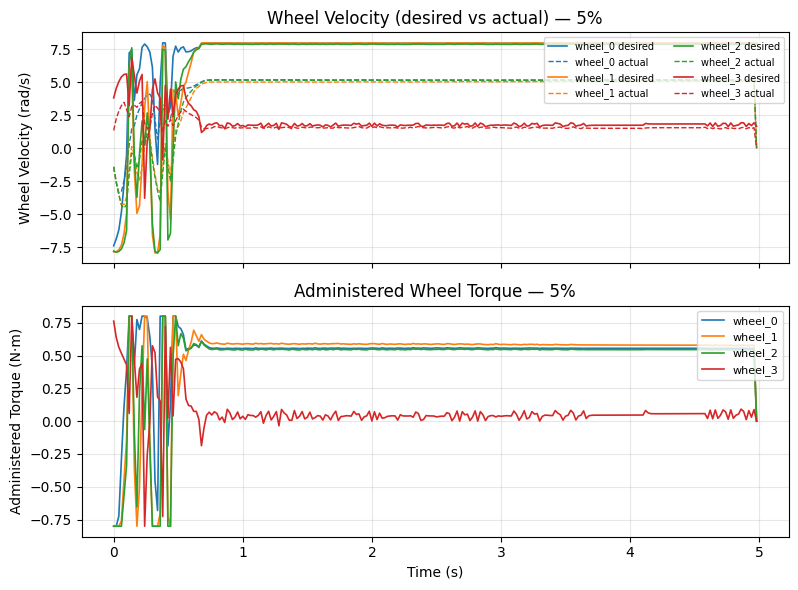

  Saved: /bigdata/rhome/jbuh2025/Transformable-Leg-Wheel-Robot/sandbox/logs/TWMRLegFlat-20260417-122122/rollout_005pct_wheel_vel.png


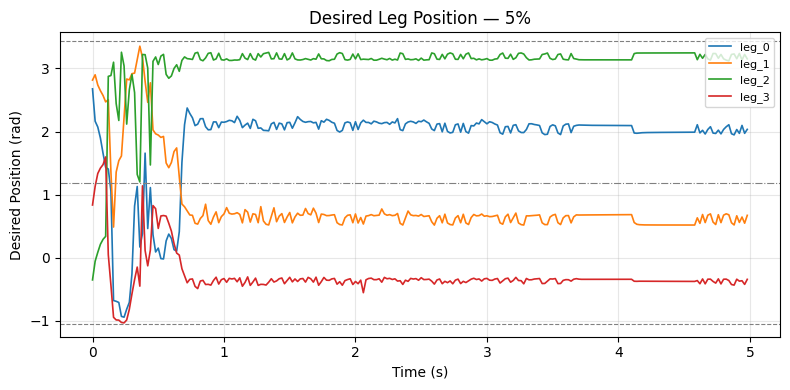

  Saved: /bigdata/rhome/jbuh2025/Transformable-Leg-Wheel-Robot/sandbox/logs/TWMRLegFlat-20260417-122122/rollout_005pct_leg_pos.png


This browser does not support the video tag.


  Saved: /bigdata/rhome/jbuh2025/Transformable-Leg-Wheel-Robot/sandbox/logs/TWMRLegFlat-20260417-122122/rollout_005pct.mp4  |  max_dist=0.506m
[  5.3%] step=  532,480  reward=24.2418  max_dist=0.496m
[ 10.6%] step=1,064,960  reward=25.6059  max_dist=0.523m
[ 16.0%] step=1,597,440  reward=28.3918  max_dist=0.580m
→ Rendering checkpoint at 21.3% (target ≥20%)…


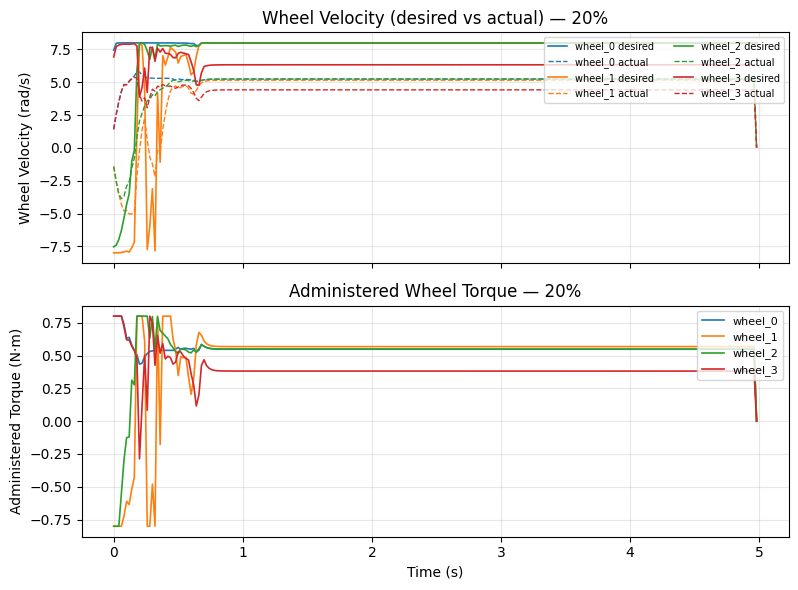

  Saved: /bigdata/rhome/jbuh2025/Transformable-Leg-Wheel-Robot/sandbox/logs/TWMRLegFlat-20260417-122122/rollout_020pct_wheel_vel.png


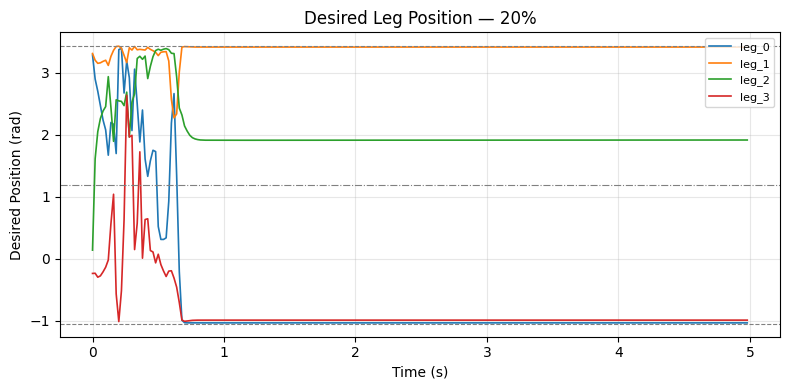

  Saved: /bigdata/rhome/jbuh2025/Transformable-Leg-Wheel-Robot/sandbox/logs/TWMRLegFlat-20260417-122122/rollout_020pct_leg_pos.png


This browser does not support the video tag.


  Saved: /bigdata/rhome/jbuh2025/Transformable-Leg-Wheel-Robot/sandbox/logs/TWMRLegFlat-20260417-122122/rollout_020pct.mp4  |  max_dist=0.589m
[ 21.3%] step=2,129,920  reward=29.0857  max_dist=0.594m
[ 26.6%] step=2,662,400  reward=29.5472  max_dist=0.603m
[ 31.9%] step=3,194,880  reward=29.7440  max_dist=0.606m
[ 37.3%] step=3,727,360  reward=30.1963  max_dist=0.616m
[ 42.6%] step=4,259,840  reward=30.5631  max_dist=0.623m
[ 47.9%] step=4,792,320  reward=30.8089  max_dist=0.628m
→ Rendering checkpoint at 53.2% (target ≥50%)…


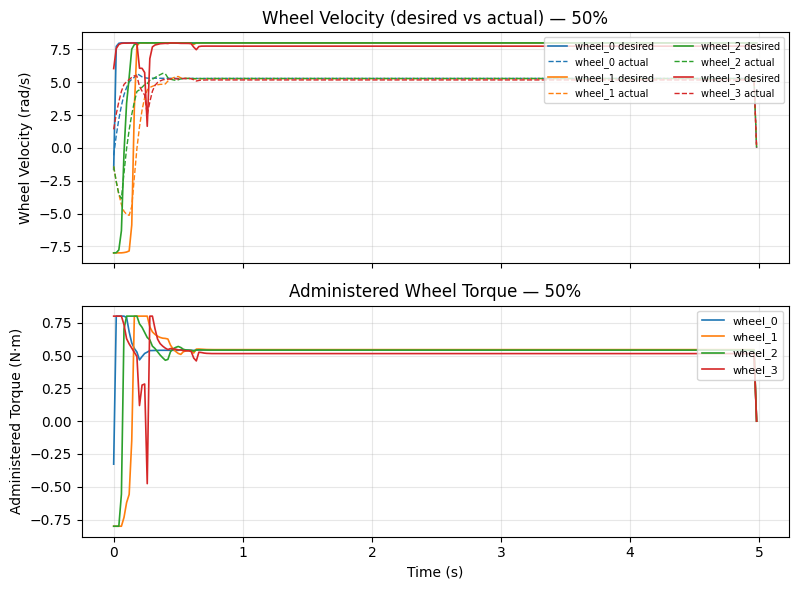

  Saved: /bigdata/rhome/jbuh2025/Transformable-Leg-Wheel-Robot/sandbox/logs/TWMRLegFlat-20260417-122122/rollout_050pct_wheel_vel.png


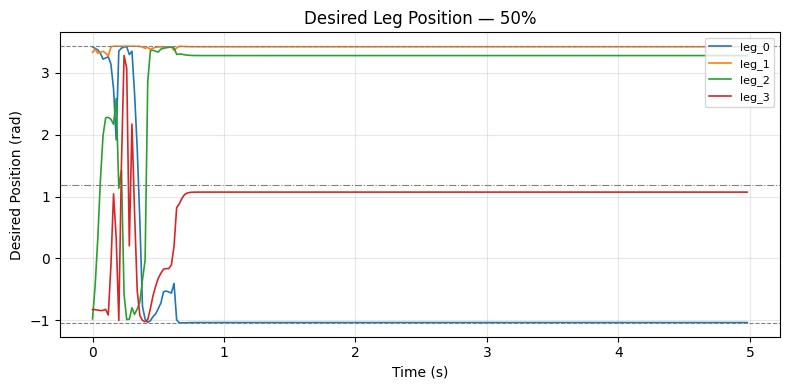

  Saved: /bigdata/rhome/jbuh2025/Transformable-Leg-Wheel-Robot/sandbox/logs/TWMRLegFlat-20260417-122122/rollout_050pct_leg_pos.png


This browser does not support the video tag.


  Saved: /bigdata/rhome/jbuh2025/Transformable-Leg-Wheel-Robot/sandbox/logs/TWMRLegFlat-20260417-122122/rollout_050pct.mp4  |  max_dist=0.632m
[ 53.2%] step=5,324,800  reward=31.0642  max_dist=0.633m
[ 58.6%] step=5,857,280  reward=31.1000  max_dist=0.634m
[ 63.9%] step=6,389,760  reward=31.1543  max_dist=0.635m
[ 69.2%] step=6,922,240  reward=31.1802  max_dist=0.635m
[ 74.5%] step=7,454,720  reward=31.1978  max_dist=0.636m
[ 79.9%] step=7,987,200  reward=31.2042  max_dist=0.636m
[ 85.2%] step=8,519,680  reward=31.2748  max_dist=0.637m
[ 90.5%] step=9,052,160  reward=31.3137  max_dist=0.638m
[ 95.8%] step=9,584,640  reward=31.3495  max_dist=0.639m
→ Rendering checkpoint at 101.2% (target ≥100%)…


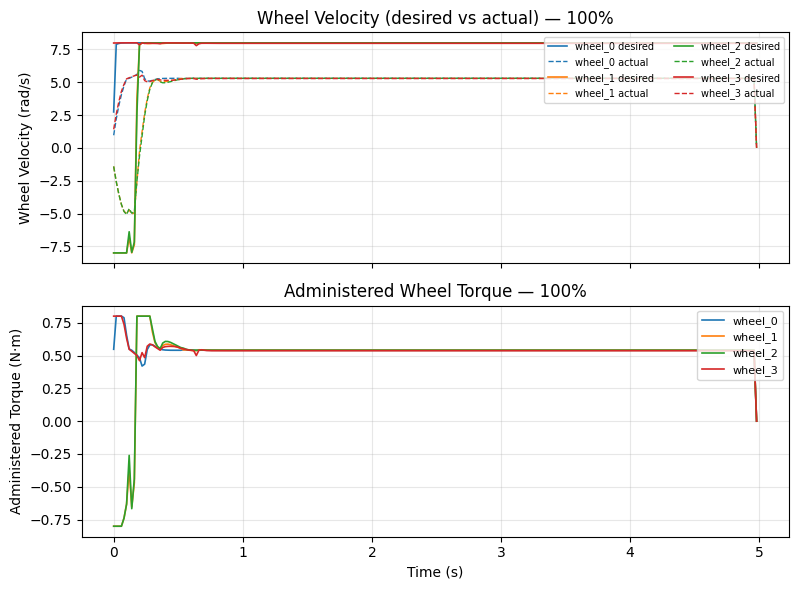

  Saved: /bigdata/rhome/jbuh2025/Transformable-Leg-Wheel-Robot/sandbox/logs/TWMRLegFlat-20260417-122122/rollout_100pct_wheel_vel.png


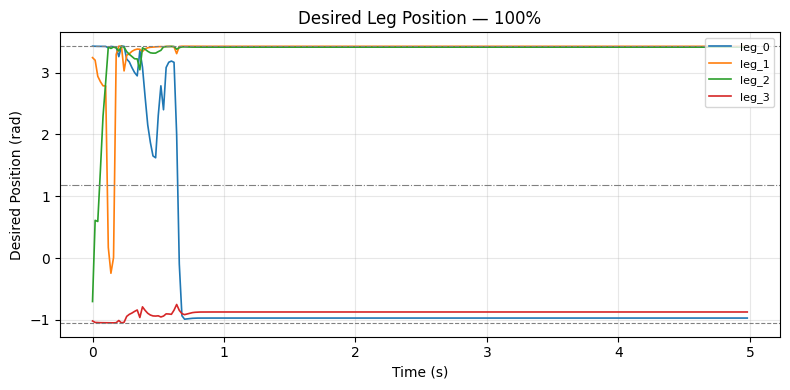

  Saved: /bigdata/rhome/jbuh2025/Transformable-Leg-Wheel-Robot/sandbox/logs/TWMRLegFlat-20260417-122122/rollout_100pct_leg_pos.png


This browser does not support the video tag.


  Saved: /bigdata/rhome/jbuh2025/Transformable-Leg-Wheel-Robot/sandbox/logs/TWMRLegFlat-20260417-122122/rollout_100pct.mp4  |  max_dist=0.637m
[101.2%] step=10,117,120  reward=31.3836  max_dist=0.639m

JIT compile time : 12.4s
Total train time : 230.5s


In [4]:
times           = [time.monotonic()]
saved_pcts      = set()
_sorted_targets = sorted(TARGET_PCTS)

# Collect (timestep, max_x_dist) at every eval for plotting
eval_steps_log: list[int]   = []
eval_dist_log:  list[float] = []


def progress(num_steps, metrics):
    times.append(time.monotonic())
    reward   = metrics.get("eval/episode_reward", float("nan"))
    max_dist = metrics.get("eval/episode_max_x_dist", float("nan"))
    pct      = num_steps / NUM_TIMESTEPS * 100
    print(f"[{pct:5.1f}%] step={num_steps:>9,}  reward={reward:.4f}  max_dist={max_dist:.3f}m")
    eval_steps_log.append(num_steps)
    eval_dist_log.append(max_dist)


def policy_params_fn(current_step, make_policy, params):
    pct = current_step / NUM_TIMESTEPS * 100
    for target in _sorted_targets:
        if pct >= target and target not in saved_pcts:
            saved_pcts.add(target)
            print(f"→ Rendering checkpoint at {pct:.1f}% (target ≥{target}%)…")
            outpath = logdir / f"rollout_{target:03d}pct.mp4"
            render_rollout(make_policy, params, outpath, label=f"{target}%")


train_fn = functools.partial(
    ppo.train,
    num_timesteps         = NUM_TIMESTEPS,
    num_evals             = NUM_EVALS,
    episode_length        = EPISODE_LENGTH,
    num_envs              = NUM_ENVS,
    unroll_length         = UNROLL_LENGTH,
    batch_size            = BATCH_SIZE,
    num_minibatches       = NUM_MINIBATCHES,
    num_updates_per_batch = NUM_UPDATES_PER_BATCH,
    learning_rate         = LEARNING_RATE,
    entropy_cost          = ENTROPY_COST,
    discounting           = DISCOUNTING,
    reward_scaling        = REWARD_SCALING,
    clipping_epsilon      = CLIPPING_EPSILON,
    max_grad_norm         = MAX_GRAD_NORM,
    normalize_observations= True,
    action_repeat         = 1,
    network_factory       = functools.partial(
        ppo_networks.make_ppo_networks,
        policy_hidden_layer_sizes = POLICY_HIDDEN,
        value_hidden_layer_sizes  = VALUE_HIDDEN,
    ),
    seed                  = SEED,
    save_checkpoint_path  = ckpt_dir,
    wrap_env_fn           = wrapper.wrap_for_brax_training,
    num_eval_envs         = NUM_EVAL_ENVS,
)

make_inference_fn, params, _ = train_fn(
    environment      = env,
    eval_env         = eval_env,
    progress_fn      = progress,
    policy_params_fn = policy_params_fn,
)

print(f"\nJIT compile time : {times[1] - times[0]:.1f}s")
print(f"Total train time : {times[-1] - times[1]:.1f}s")

# # ── Plot: max forward distance vs training timesteps ─────────────────────────
# fig, ax = plt.subplots(figsize=(8, 4))
# ax.plot(eval_steps_log/10e6, eval_dist_log, marker="o", markersize=4, linewidth=1.5)
# ax.set_xlabel("Training Timesteps (1e6)")
# ax.set_ylabel("Max Forward Distance (m)")
# ax.set_title("Max +x Distance Reached per Episode During Training")
# ax.grid(True, alpha=0.3)
# fig.tight_layout()
# fig.savefig(str(logdir / "max_x_dist_vs_steps.png"), dpi=150)
# plt.show()
# print(f"  Plot saved: {logdir / 'max_x_dist_vs_steps.png'}")

In [ ]:
# ── Plot: max forward distance vs training timesteps ─────────────────────────
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(np.array(eval_steps_log)/1e6, eval_dist_log, marker="o", markersize=4, linewidth=1.5)
ax.set_xlabel("Training Timesteps (10^6)")
ax.set_ylabel("Max Forward Distance (m)")
ax.set_title("Max +x Distance Reached per Episode During Training")
ax.grid(True, alpha=0.3)
fig.tight_layout()
fig.savefig(str(logdir / "max_x_dist_vs_steps.png"), dpi=150)
plt.show()
print(f"  Plot saved: {logdir / 'max_x_dist_vs_steps.png'}")

print("Rendering final rollout…")
frames = render_rollout(make_inference_fn, params, logdir / "rollout_final.mp4", label="final")
media.show_video(frames, fps=1.0 / _render_env.dt)